У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib

In [2]:
data = pd.read_csv('train.csv.zip')
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')
data.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



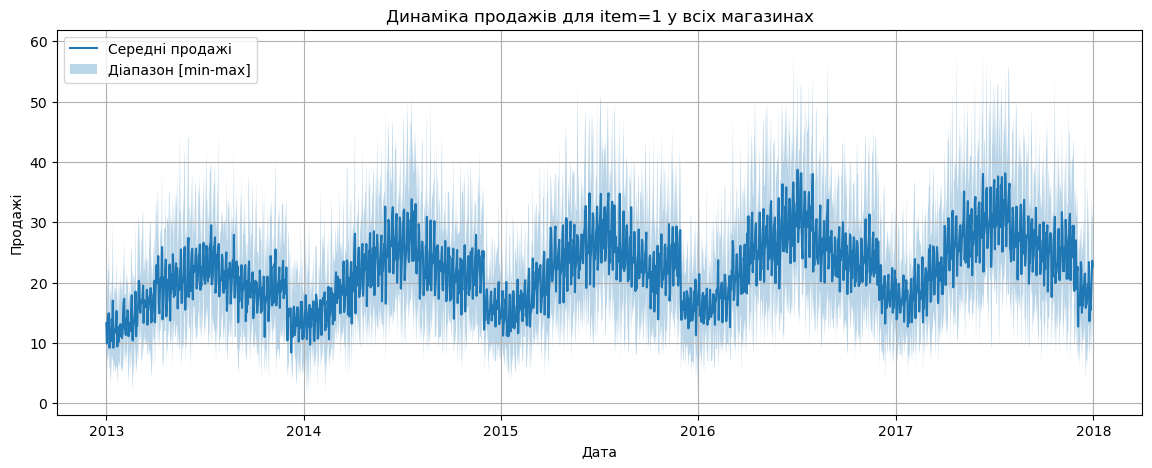

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

item_1 = data[data['item'] == 1]
item_1_grouped = item_1.groupby('date')['sales'].agg(['mean', 'min', 'max'])
plt.figure(figsize=(14, 5))
plt.plot(item_1_grouped.index, item_1_grouped['mean'], label='Середні продажі')
plt.fill_between(item_1_grouped.index, item_1_grouped['min'], item_1_grouped['max'], alpha=0.3, label='Діапазон [min-max]')
plt.title('Динаміка продажів для item=1 у всіх магазинах')
plt.xlabel('Дата')
plt.ylabel('Продажі')
plt.legend()
plt.grid(True)
plt.show()

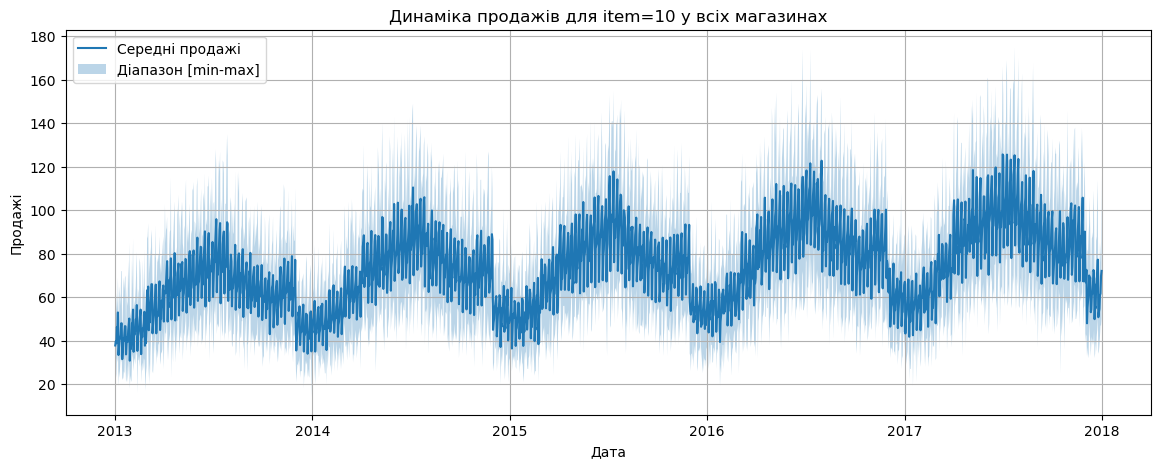

In [5]:
item_10 = data[data['item'] == 10]
item_10_grouped = item_10.groupby('date')['sales'].agg(['mean', 'min', 'max'])
plt.figure(figsize=(14, 5))
plt.plot(item_10_grouped.index, item_10_grouped['mean'], label='Середні продажі')
plt.fill_between(item_10_grouped.index, item_10_grouped['min'], item_10_grouped['max'], alpha=0.3, label='Діапазон [min-max]')
plt.title('Динаміка продажів для item=10 у всіх магазинах')
plt.xlabel('Дата')
plt.ylabel('Продажі')
plt.legend()
plt.grid(True)
plt.show()

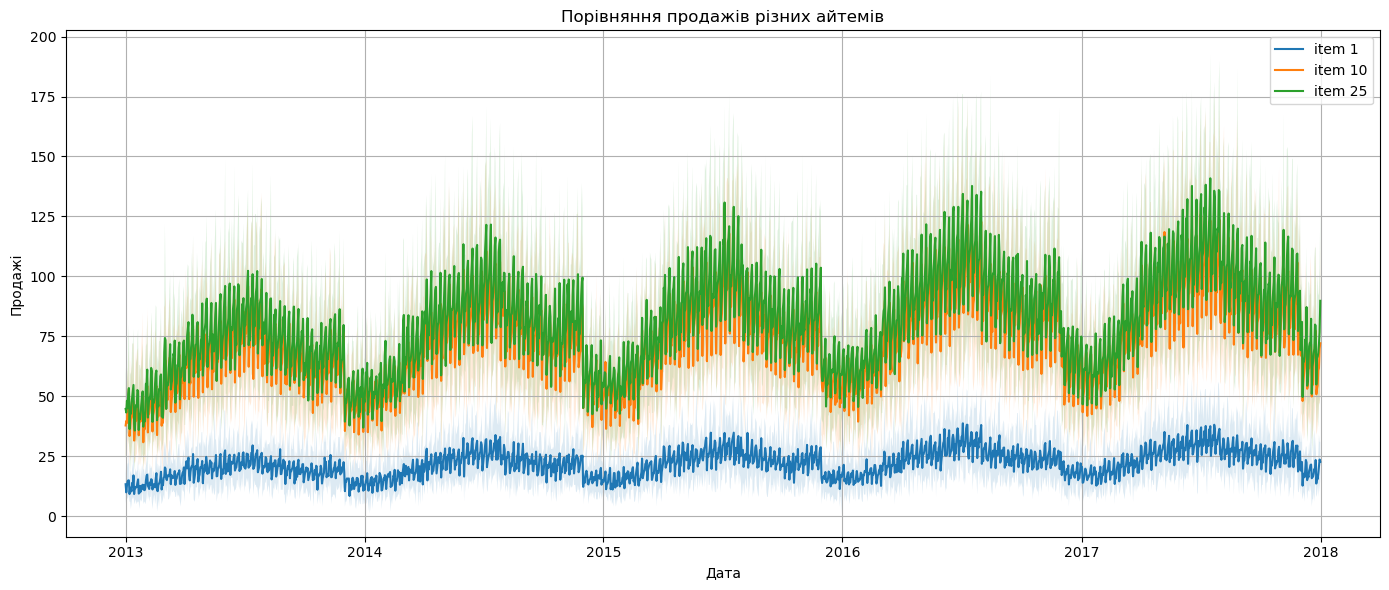

In [6]:
items_to_plot = [1, 10, 25]
plt.figure(figsize=(14, 6))

for item_id in items_to_plot:
    item_data = data[data['item'] == item_id]
    item_grouped = item_data.groupby('date')['sales'].agg(['mean', 'min', 'max'])
    
    # линия — среднее
    plt.plot(item_grouped.index, item_grouped['mean'], label=f'item {item_id}')
    
    # прозрачная область — разброс
    plt.fill_between(item_grouped.index, item_grouped['min'], item_grouped['max'], alpha=0.15)

plt.title('Порівняння продажів різних айтемів')
plt.xlabel('Дата')
plt.ylabel('Продажі')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

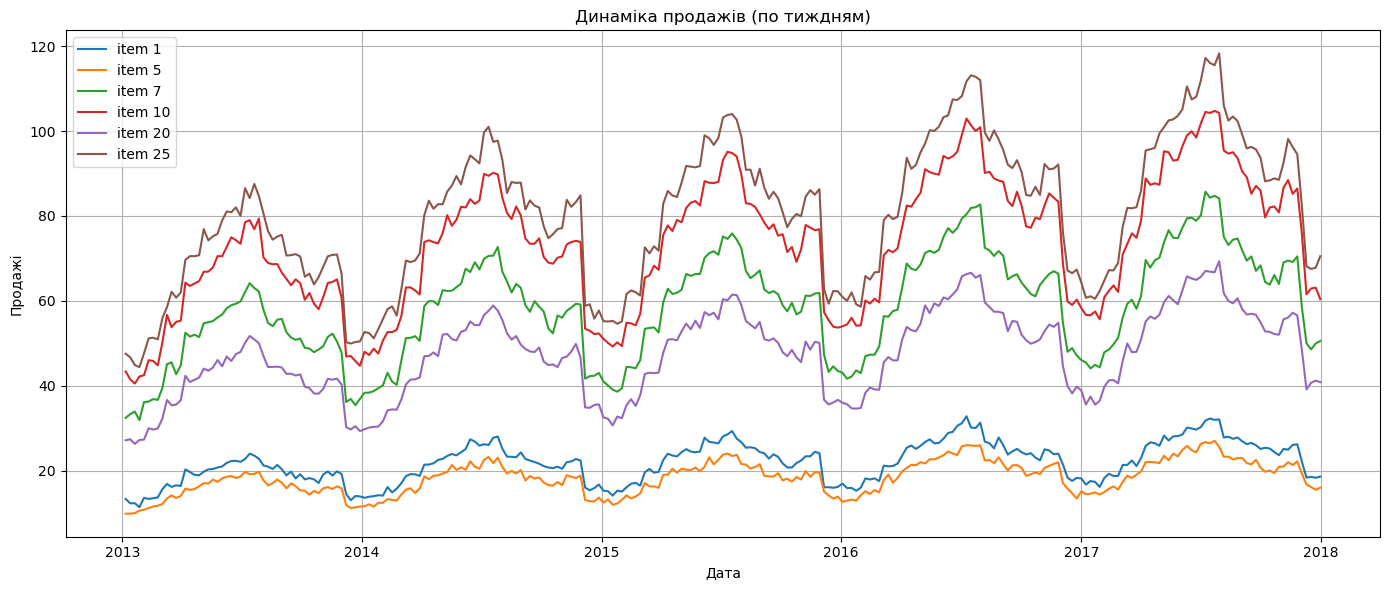

In [7]:
items_to_plot = [1, 5, 7, 10, 20, 25]
plt.figure(figsize=(14, 6))

for item_id in items_to_plot:
    item_data = data[data['item'] == item_id]
    
    weekly = item_data.groupby([pd.Grouper(freq='W')])['sales'].agg(['mean', 'min', 'max'])

    plt.plot(weekly.index, weekly['mean'], label=f'item {item_id}')

plt.title('Динаміка продажів (по тиждням)')
plt.xlabel('Дата')
plt.ylabel('Продажі')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Продажі товарів відрізняються і продажі в різних магазинів також, але чітко видно сезонність і невелику лінію тренду

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [8]:
item1_shop1 = data[(data['item'] == 1) & (data['store'] == 1)]

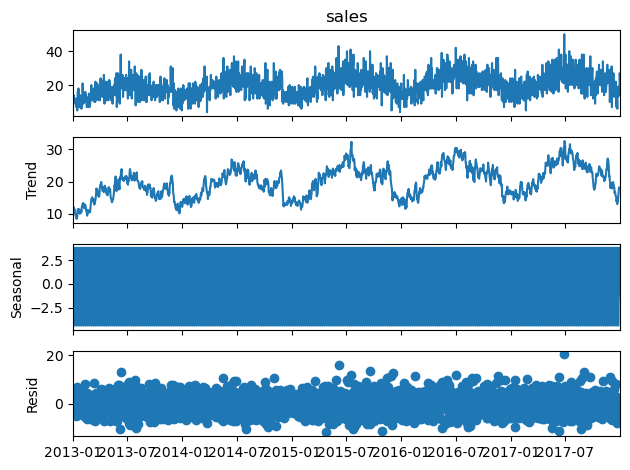

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition_plot_multi = seasonal_decompose(item1_shop1['sales'],
                                              model='additive')
decomposition_plot_multi.plot()
plt.show()

З цієї візуалізації майже нічого не зрозуміло, тому я спробувала згрупувати дані по тижнях і чітко побачила тренд, сезонність і помилки.

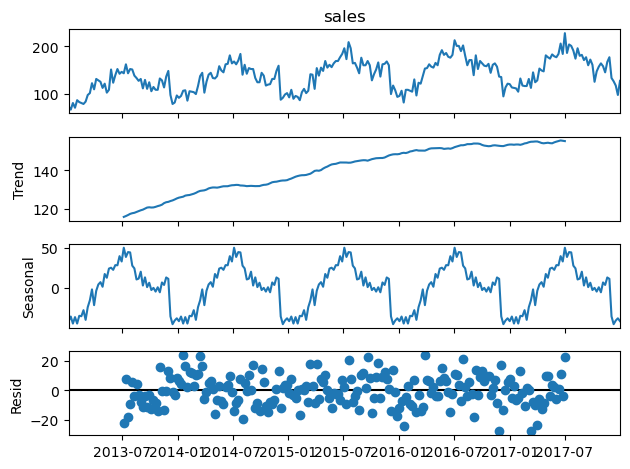

In [10]:
weekly_sales = item1_shop1['sales'].resample('W').sum()

decomposition = seasonal_decompose(weekly_sales, model='additive')
decomposition.plot()
plt.show()

 Сезонність дуже чітко повторюється, тренд маємо зростаючій. Помилки мають досить великий розкид нажаль, але не мають паттернів, що добре

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [11]:
from darts import TimeSeries

series = TimeSeries.from_dataframe(item1_shop1, value_cols='sales')

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

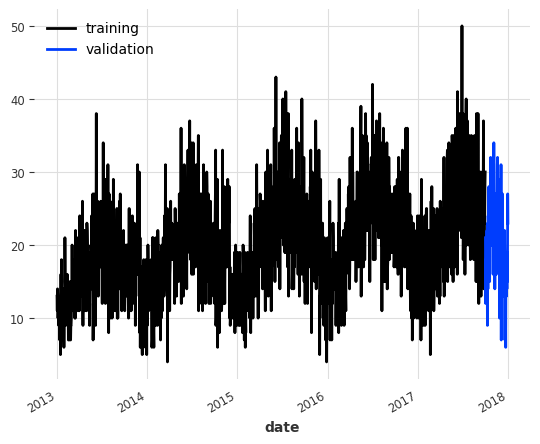

In [32]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

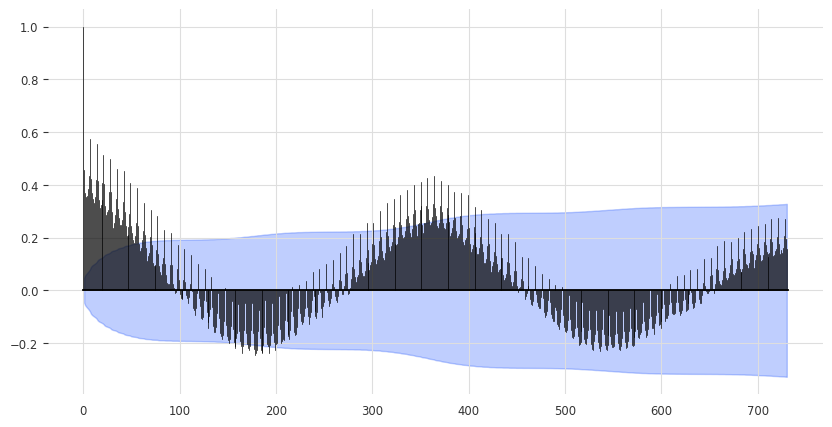

In [13]:
from darts.utils.statistics import plot_acf, check_seasonality

plot_acf(train, alpha=0.05, max_lag=730)

На початку всі стовбці виходять за довірчий інтервал. Кожних сім днів лаг має вищу кореляцію. Бачим тижневу сезонність.
Подумала я спочатку, а потім перебудувала автокореляційну функцію для більшого періоду і побачила, що річна сезонність більш глобальна

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [14]:
for m in range(2, 730):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05, max_lag=750)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.
There is seasonality of order 28.
There is seasonality of order 35.
There is seasonality of order 42.
There is seasonality of order 49.
There is seasonality of order 56.
There is seasonality of order 63.
There is seasonality of order 70.
There is seasonality of order 74.
There is seasonality of order 77.
There is seasonality of order 84.
There is seasonality of order 91.
There is seasonality of order 98.
There is seasonality of order 105.
There is seasonality of order 112.
There is seasonality of order 119.
There is seasonality of order 126.
There is seasonality of order 133.
There is seasonality of order 224.
There is seasonality of order 231.
There is seasonality of order 238.
There is seasonality of order 245.
There is seasonality of order 252.
There is seasonality of order 259.
There is seasonality of order 266.
There is seasonality of order 273.
There is seasonality of order 280.
T

Результат з сезонністю 7 мені зовсім не сподобався, виглядає ніби сезонність по роках більш значуща, але ця функція її не бачить

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<Axes: xlabel='date'>

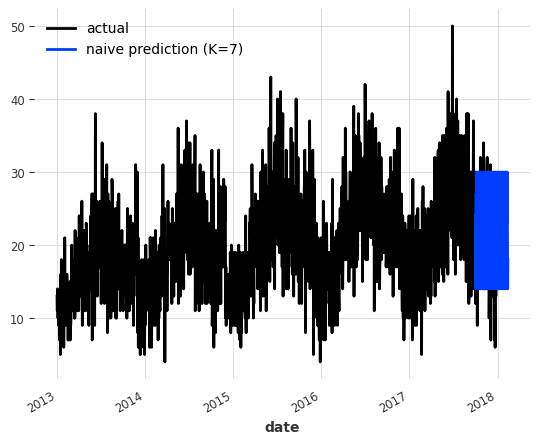

In [15]:
from darts.models import NaiveSeasonal

seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(136)

series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=7)")

Неможливо нічого побачити через купу даних, пробую вивести останній рік

<Axes: xlabel='date'>

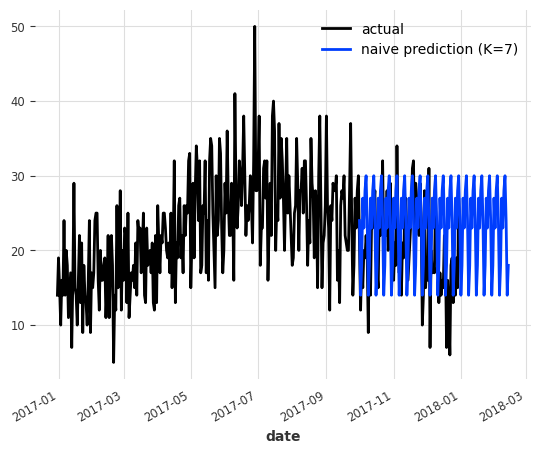

In [16]:
year_ago = series.time_index[-1] - pd.DateOffset(years=1)

series_last2y = series.slice(year_ago, series.time_index[-1])
forecast_last2y = seasonal_forecast.slice(year_ago, seasonal_forecast.time_index[-1])

series_last2y.plot(label="actual")
forecast_last2y.plot(label="naive prediction (K=7)")

Все ще не дуже, і передбачення далеке від правди, пробую сгладити дані

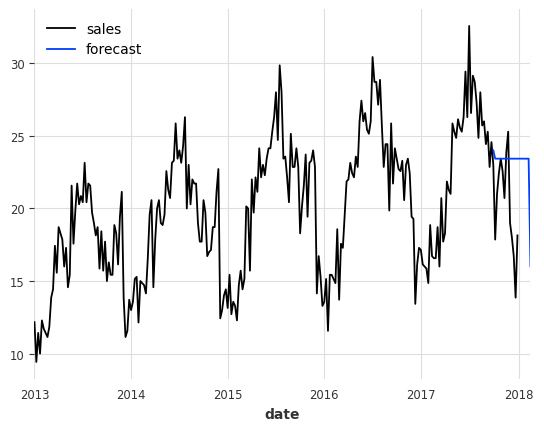

In [17]:
def smooth_and_plot(series, seasonal_forecast):
    two_years_ago = series.time_index[-1] - pd.DateOffset(years=2)
    
    #series_last2y = series.slice(two_years_ago, series.time_index[-1])
    #forecast_last2y = seasonal_forecast.slice(two_years_ago, seasonal_forecast.time_index[-1])
    
    forecast_df = seasonal_forecast.to_dataframe()
    series_df = series.to_dataframe()
    
    forecast_series = forecast_df[forecast_df.columns[0]]
    
    smoothed_forecast = forecast_series.resample('W').mean()
    smoothed_series = series_df.resample('W').mean()
    
    smoothed_series.plot(label="actual")
    smoothed_forecast.plot(label="forecast")
    plt.legend()  
    plt.show()

smooth_and_plot(series, seasonal_forecast)

Сглажую дані і розумію, що якщо в мене сезонність 7 днів і сглажую я по тижнях то ось вона і виходить пряма. Спробую навчити цю модель з сезонністю в рік. І здається треба виносити цей шматок візуалізації в функцію... :)

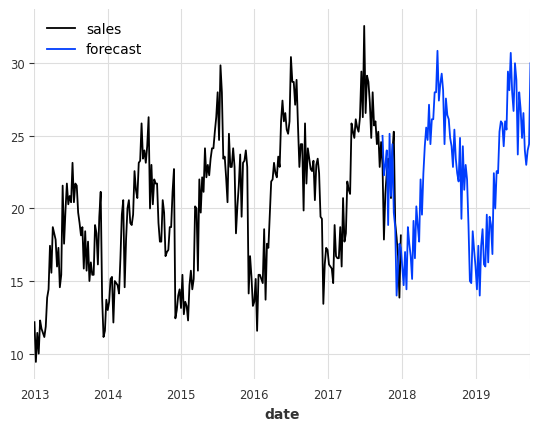

In [18]:
seasonal_model365 = NaiveSeasonal(K=365)
seasonal_model365.fit(train)
seasonal_forecast365 = seasonal_model365.predict(730)

smooth_and_plot(series, seasonal_forecast365)

Виглядає набагато краще, тепер можна додати тренд

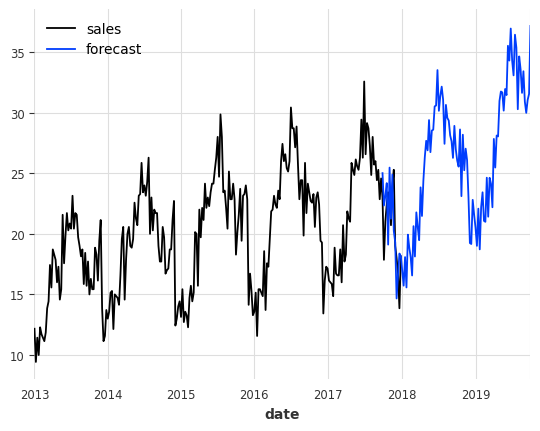

In [19]:
from darts.models import NaiveDrift

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(730)

combined_forecast = drift_forecast + seasonal_forecast365 - train.last_value()
smooth_and_plot(series, combined_forecast)

Я зробила передбачення на два роки, які вилазять за наші існуючі дані, щоб було видно як допомагає тренд. Але там де прогноз з існуючими даними перетинаються видно, що прогноз приблизно співпадає з даними. Виглядає досить непогано

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [20]:
from darts.metrics import mape

print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(series, combined_forecast):.2f}%."
)

Mean absolute percentage error for the combined naive drift + seasonal: 34.26%.


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

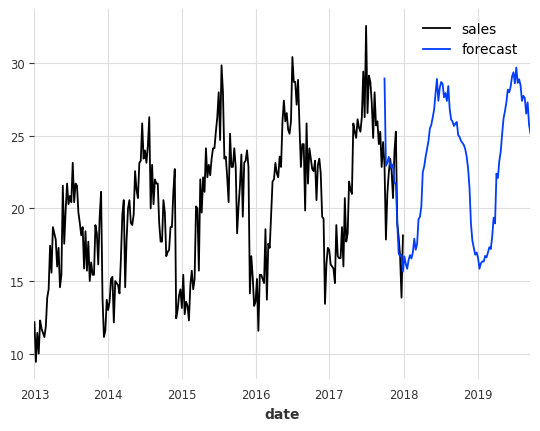

Mean absolute percentage error for the XGBModel: 23.62%.


In [21]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

def enrich_with_date_features(df):
    df["date"] = pd.to_datetime(df["date"])

    df["dayofweek"] = df['date'].dt.dayofweek        
    df["quarter"] = df['date'].dt.quarter
    df["month"] = df['date'].dt.month
    df["year"] = df['date'].dt.year
    df["weekofyear"] = df['date'].dt.isocalendar().week.astype(int)
    df["dayofyear"] = df['date'].dt.dayofyear
    df["dayofmonth"] = df['date'].dt.day
    
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    
    df["sin_day"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["cos_day"] = np.cos(2 * np.pi * df["dayofyear"] / 365)
    
    df["sin_week"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["cos_week"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    
    return df

# Додавання ознак дати
train_transformed = enrich_with_date_features(train.to_dataframe().reset_index())
val_transformed = enrich_with_date_features(val.to_dataframe().reset_index())

train_cov = TimeSeries.from_dataframe(
    train_transformed, 
    time_col="date", 
    value_cols=[
        "dayofweek", "quarter", "month", "year", "weekofyear",
        "dayofyear", "dayofmonth", "is_weekend",
        "sin_day", "cos_day", "sin_week", "cos_week"
    ]
)

val_cov = TimeSeries.from_dataframe(
    val_transformed, 
    time_col="date", 
    value_cols=[
        "dayofweek", "quarter", "month", "year", "weekofyear",
        "dayofyear", "dayofmonth", "is_weekend",
        "sin_day", "cos_day", "sin_week", "cos_week"
    ]
)

scaler = Scaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(val)

model_XGB = XGBModel(
    lags=1095,  # Використання останніх 12 спостережень для прогнозування
    lags_future_covariates=[0], 
    output_chunk_length=1,  # Прогнозування на 1 крок вперед
    n_estimators=100,  # Кількість дерев у моделі
    max_depth=3,  # Максимальна глибина кожного дерева
    learning_rate=0.1,  # Коефіцієнт навчання
    subsample=0.8,  # Частка даних для випадкової вибірки кожного дерева
    colsample_bytree=0.8  # Частка ознак, що використовуються для кожного дерева
)

# Тренування моделі
# model_XGB.fit(train_scaled)
model_XGB.fit(series=train_scaled, future_covariates=train_cov)

full_dates = pd.date_range(
    start=train.time_index[0],
    end=series.time_index[-1] + pd.Timedelta(days=720),
    freq="D"
)
df_full = pd.DataFrame({"date": full_dates})

df_full = enrich_with_date_features(df_full)

covariates = TimeSeries.from_dataframe(df_full, time_col="date")

train_cov = covariates.slice(train.start_time(), train.end_time())
val_cov = covariates.slice(val.start_time(), val.end_time())
future_cov = covariates

forecast_XGB = scaler.inverse_transform(model_XGB.predict(720, future_covariates=future_cov))
smooth_and_plot(series, forecast_XGB)

print(
    f"Mean absolute percentage error for the XGBModel: {mape(series, forecast_XGB):.2f}%."
)


Зберегла результат моделі без додавання ознак з дати:
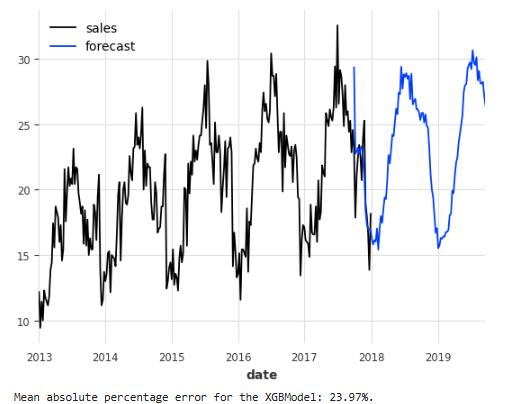

Загалом ця модель краща ніж попередня за mape, хоча на графіку здається, що вона не так точно повторює оригінальні дані. Напевно через те, що тут прогноз більш сглажений, і тому помилки менші.
Також бачимо, що додовання ознак трохи покращило показник mape

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

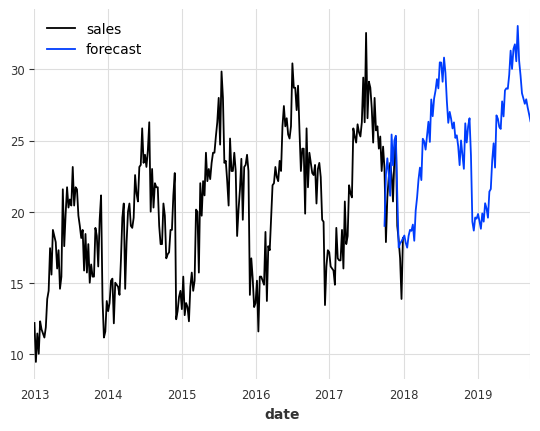

model ExponentialSmoothing(seasonal_periods=365) obtains MAPE: 28.64%


In [22]:
from darts.models import ExponentialSmoothing

def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(720)
  smooth_and_plot(series, forecast)
  eval_forecast(model, val, forecast);

modelES = ExponentialSmoothing(seasonal_periods=365)
fit_and_plot(modelES, series, train, val)
#fit_eval_model(AutoARIMA())
#fit_eval_model(Theta())

Прогноз виглядає напогано, але її точність гірша ніж XGBoost

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


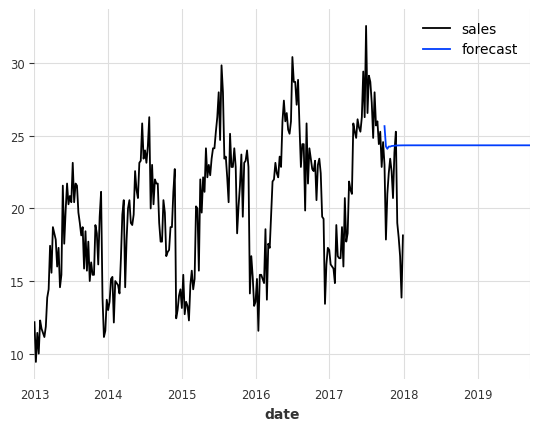

model ARIMA(p=14, q=1) obtains MAPE: 39.23%


In [24]:
from darts.models import ARIMA

# Побудова та тренування моделі ARIMA
modelAR = ARIMA(p=14, d=1, q=1) #try p=12
fit_and_plot(modelAR, series, train, val)

ARIMA не дуже добре впоралась, можливо тому, що в нас сезонність 365, а для неї це занадто багато, а з p=7 aбо 14 прогноз м'ягко кажучи не дуже

C:\Users\hp\AppData\Local\Temp\ipykernel_7952\1267145826.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = item1_shop1['sales'].resample('M').sum().reset_index()
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


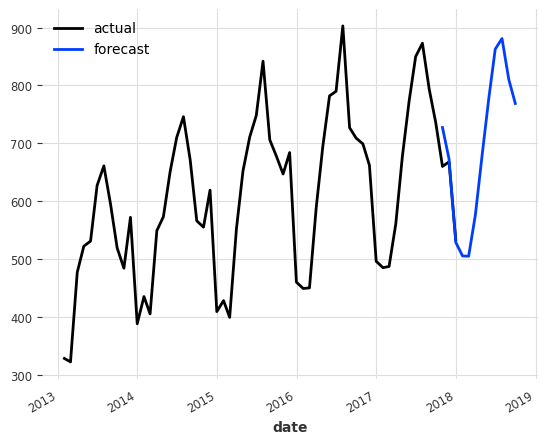

Mean absolute percentage error for the ARIMA: 3.92%.


In [25]:
monthly_sales = item1_shop1['sales'].resample('M').sum().reset_index()

series_m = TimeSeries.from_dataframe(monthly_sales, time_col='date', value_cols='sales')

train_m, val_m = series_m.split_before(pd.Timestamp("2017-10-31"))

modelARM = ARIMA(p=12, d=1, q=1)
modelARM.fit(train_m)

forecast_m = modelARM.predict(12)

series_m.plot(label="actual")
forecast_m.plot(label="forecast")
plt.legend()
plt.show()

print(
    f"Mean absolute percentage error for the ARIMA: {mape(series_m, forecast_m):.2f}%."
)

Наприклад, якщо згрупувати дані по місяцях, вона набагато краще себе показала

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=8, max_p=20, start_q=1)

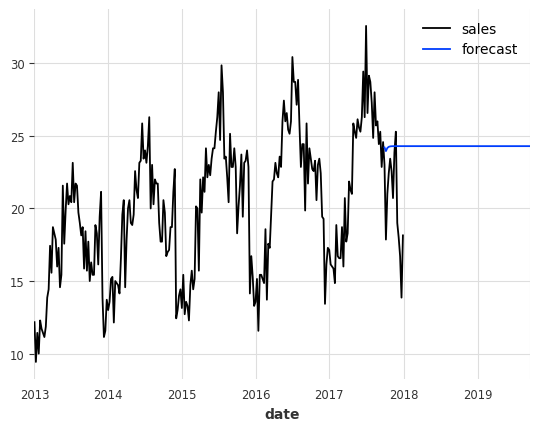

In [26]:
from darts.models import AutoARIMA

modelAAR = AutoARIMA(start_p=8, max_p=20, start_q=1) # спробуйте стартувати з інших значень і перегляньте, що виходить
modelAAR.fit(train)

display(modelAAR)

# Прогнозування
forecast_AAR = modelAAR.predict(720)

# Візуалізація результатів
smooth_and_plot(series, forecast_AAR)

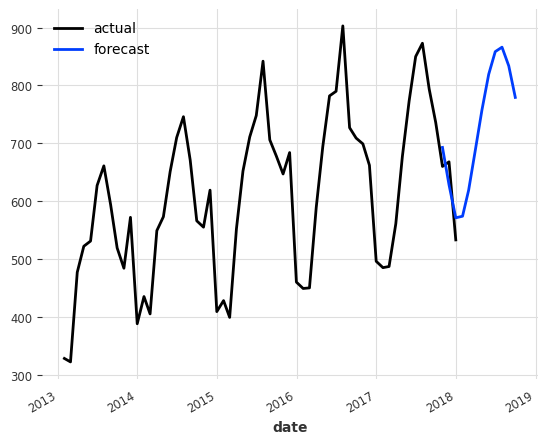

Mean absolute percentage error for the AutoARIMA: 6.03%.


In [27]:
modelAARM = AutoARIMA(start_p=8, max_p=12, start_q=1) # спробуйте стартувати з інших значень і перегляньте, що виходить
modelAARM.fit(train_m)


# Прогнозування
forecast_AARM = modelAARM.predict(12)

series_m.plot(label="actual")
forecast_AARM.plot(label="forecast")
plt.legend()
plt.show()

print(
    f"Mean absolute percentage error for the AutoARIMA: {mape(series_m, forecast_AARM):.2f}%."
)

На візуалізації модель дуже точно передбачає частину, але трошки зарано починає зростати, і через це і неї mape більше ніж в попередньої моделі. Так само як ARIMA, autoARIMA не дуже може передбачати дані по днях, а з помісячними даними їй простіше. Загалом модель досить непогана

In [28]:
sf_model = modelAARM.model          
best = sf_model.model_              

p, d, q, P, D, Q, m = best['arma']

print("Найкращі параметри моделі (SARIMA):")
print(f"  (p, d, q) = ({p}, {d}, {q})")
print(f"  (P, D, Q, m) = ({P}, {D}, {Q}, {m}) ")
print()
print(f"AIC = {best['aic']:.2f}")
print(f"BIC = {best['bic']:.2f}")
print(f"LogLik = {best['loglik']:.2f}")
print()
print("Коэффіціенти моделі:")
for coef_name, coef_value in best['coef'].items():
    print(f"  {coef_name}: {coef_value:.4f}")

Найкращі параметри моделі (SARIMA):
  (p, d, q) = (7, 1, 0)
  (P, D, Q, m) = (0, 1, 1, 0) 

AIC = 639.27
BIC = 659.52
LogLik = -309.64

Коэффіціенти моделі:
  ar1: 0.3354
  ar2: -0.0645
  ar3: -0.1661
  ar4: 0.1174
  ar5: -0.4357
  ar6: -0.1182
  ar7: -0.2685
  ma1: -0.8686
  drift: 3.9645


Так як було наведено в лекції не працює, здається в Darts немає такого методу. Зробила трошки інакше

14. Натренуйте модель Prophet та зробіть висновок про її якість.

15:31:02 - cmdstanpy - INFO - Chain [1] start processing
15:31:02 - cmdstanpy - INFO - Chain [1] done processing


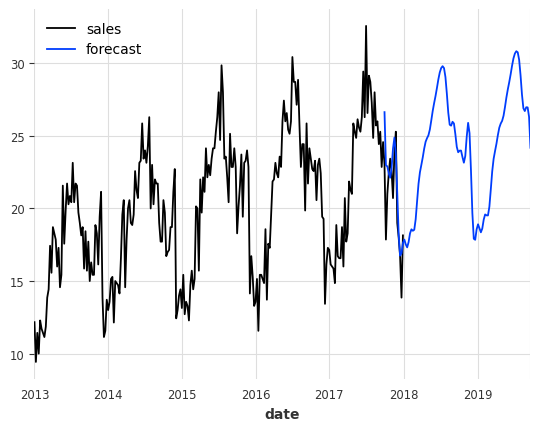

In [29]:
from darts.models import Prophet

# Побудова та тренування моделі Prophet
model_Prophet = Prophet()
model_Prophet.fit(train)

# Прогнозування
forecast_Prophet = model_Prophet.predict(720)
smooth_and_plot(series, forecast_Prophet)

In [30]:
print(
    f"Mean absolute percentage error for the Prophet: {mape(series, forecast_Prophet):.2f}%."
)

Mean absolute percentage error for the Prophet: 23.80%.


Ця модель трошки гірша ніж XGBoost, але показала себе на рівні

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.023     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

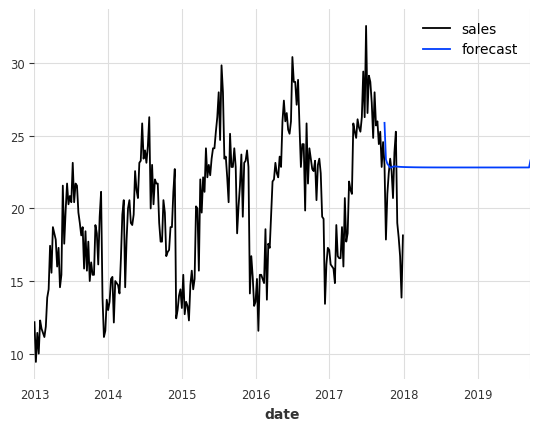

model RNNModel(model=LSTM, input_chunk_length=12, n_epochs=300) obtains MAPE: 36.61%


In [31]:
from darts.models import RNNModel

# Побудова та тренування моделі LSTM
modelRNM = RNNModel(model='LSTM', input_chunk_length=12, n_epochs=300)
fit_and_plot(modelRNM, series, train, val)

In [58]:
from darts.utils.timeseries_generation import datetime_attribute_timeseries

scaler = Scaler()
train_transformed = scaler.fit_transform(train)
val_transformed = scaler.transform(val)
series_transformed = scaler.transform(series)

time_index = pd.date_range(
    start=series.start_time(),
    end=train.end_time() + pd.Timedelta(days=720),
    freq=series.freq_str
)

year_series = datetime_attribute_timeseries(time_index, attribute="year", one_hot=False)
month_series = datetime_attribute_timeseries(time_index, attribute="month", one_hot=True)
day_series = datetime_attribute_timeseries(time_index, attribute="day", one_hot=False)
weekday_series = datetime_attribute_timeseries(time_index, attribute="day_of_week", one_hot=True)

year_series = Scaler().fit_transform(year_series)
day_series = Scaler().fit_transform(day_series)

covariates = year_series.stack(month_series).stack(day_series).stack(weekday_series)

cov_train, cov_val = covariates.split_after(val.start_time() - pd.Timedelta(days=1))

model_RNN = RNNModel(
    model="LSTM",
    input_chunk_length=30,   # окно входа (30 дней)
    training_length=40,      # окно train = вход + выход
    hidden_dim=20,
    dropout=0,
    batch_size=16,
    n_epochs=100,
    optimizer_kwargs={"lr": 1e-3},
    log_tensorboard=True,
    random_state=42,
    force_reset=True,
)

model_RNN.fit(
    train_transformed,
    future_covariates=cov_train,
    val_series=val_transformed,
    val_future_covariates=cov_val,
    verbose=True
)

forecast_RNN = scaler.inverse_transform(
    model_RNN.predict(n=720, future_covariates=covariates)
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | eval 
1 | train_criterion | MSELoss          | 0      | eval 
2 | val_criterion   | MSELoss          | 0      | eval 
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 3.5 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
3.5 K     Trainable params
0         Non-trainable params
3.5 K     Total params
0.028     Total estimated model params size (MB)
4         Modules in train mode
3         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

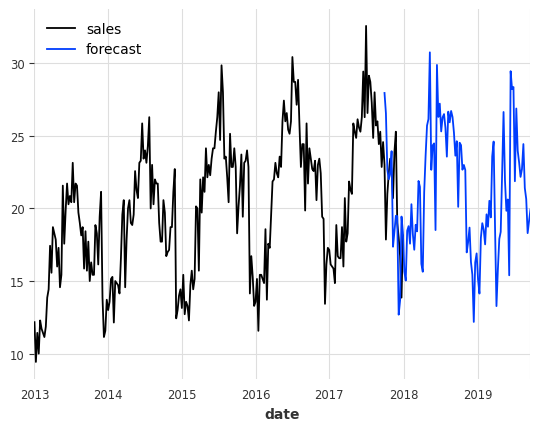

Mean absolute percentage error for the RNN: 37.92%.


In [62]:
smooth_and_plot(series, forecast_RNN)

print(
    f"Mean absolute percentage error for the RNN: {mape(series, forecast_RNN):.2f}%."
)

Не найкраща модель, прогнози схожі на правду, але вона не врахувала тренд і ми бачили прогнози поточніше. І ці всі результати тільки після додаваня додаткових ознак. До того модель взагалі не впоралась

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

historical forecasts:   0%|          | 0/12 [00:00<?, ?it/s]

14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:47 - cmdstanpy - INFO - Chain [1] done processing
14:17:47 - cmdstanpy - INFO - Chain [1] start processing
14:17:47 - cmdstanpy - INFO - Chain [1] done processing
14:17:47 - cmdstanpy - INFO - Chain [1] start processing
14:17:47 - cmdstanpy - INFO - Chain [1] done processing
14:17:47 - cmdstanpy - INFO - Chain [1] start processing
14:17:47 - cmdstanpy - INFO - Chain [1] done processing
14:17:47 - cmdstanpy - INFO - Chain [1] start processing
14:17:47 - cmdstanpy - INFO - Chain [1] done processing
14:17:48 - cmdstanpy - INFO - Chain [1] start processing
14:17:48 - cmdstanpy - INFO - Chain [1]

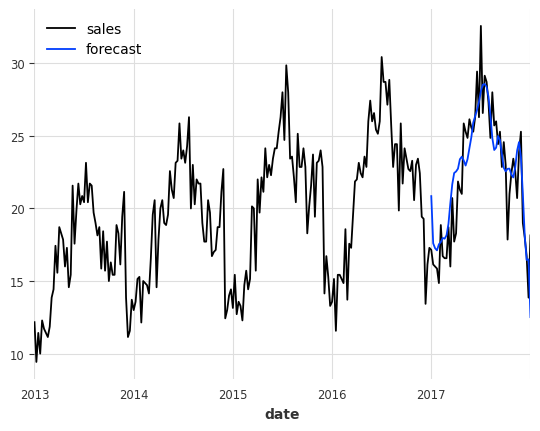

MAPE = 21.31%


In [80]:
from darts import concatenate

hfc_params = {
    "series": series,
    # стартуем ровно за год до конца
    "start": series.end_time() - pd.Timedelta(days=365),
    # прогноз на 30 дней вперёд
    "forecast_horizon": 30,
    # делаем шаг в 1 день, чтобы прогнозы не терялись
    "stride": 30,
    # сохраняем все точки прогноза
    "last_points_only": False,
    "verbose": True,
}

historical_fcast_list = model_Prophet.historical_forecasts(**hfc_params)
historical_fcast = concatenate(historical_fcast_list)

smooth_and_plot(series, historical_fcast)
print(f"MAPE = {mape(series, historical_fcast):.2f}%")

Я обрала Prophet тому що вона швидко навчається і досить точна. На бектесті вона показала себе навіть краще ніж при навчанні на валідації.

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Як варіант зробити дані помісячними, тоді моделі швидше навчаються, і показують точніший результат. На місячних даних непогано себе показала ARIMA, з поденними гарно впоралась Prophet. Але для точності треба їх всі протестувати на помісячних даних та подивитись як вони всі поводяться на бектесті.
Для максимальної точності, і якщо модель не дуже довго навчається, можна навчити всі 500 моделей в циклі. Це займе деякий час, але дасть найкращій результат.
Якщо потрібно швидше, можна додати ознаки наприклад номер магазину і натренувати модель для одного айтему і всіх магазинів. Це має сенс, якщо продажі одного товару в різних магазинах не дуже відрізняються